In [1]:
!pip install xgboost imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [3]:
transaction = pd.read_csv('/content/train_transaction.csv')
identity = pd.read_csv('/content/train_identity.csv')
data = transaction.merge(identity, on='TransactionID', how='left')
print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (22881, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [4]:
data = data.loc[:, data.isnull().mean() < 0.5]
for col in data.select_dtypes(include=np.number).columns:
    data[col] = data[col].fillna(data[col].median())
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].fillna(data[col].mode()[0])
print("Missing values handled")
print(data.shape)

Missing values handled
(22881, 185)


In [5]:
label_encoder = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = label_encoder.fit_transform(data[col])
print("Encoding completed")

Encoding completed


In [6]:
X = data.drop(['isFraud'], axis=1)
y = data['isFraud']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (18304, 184)
Test shape: (4577, 184)


In [7]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)
print("SMOTE applied")
print(y_train_smote.value_counts())

SMOTE applied
isFraud
0    17785
1    17785
Name: count, dtype: int64


In [8]:
model = XGBClassifier(
    n_estimators=50,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train_smote, y_train_smote)
print("Model trained successfully")

Model trained successfully


In [9]:
y_pred = model.predict(X_test)
print("Prediction completed")

Prediction completed


In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9661350229407909
Precision: 0.40268456375838924
Recall: 0.47619047619047616
F1 Score: 0.43636363636363634


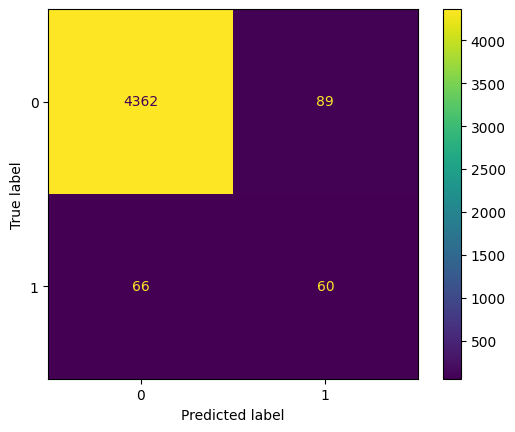

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [12]:
from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(y_test, y_pred)
print("AUC-ROC Score:", auc_score)

AUC-ROC Score: 0.7280974847813761


In [13]:
import joblib
joblib.dump(model, 'fraud_detection_model.pkl')
print("Model saved successfully")

Model saved successfully


In [14]:
sample_data = X_test.iloc[0:1]
prediction = model.predict(sample_data)
if prediction[0] == 1:
    print("Fraud Transaction Detected")
else:
    print("Legitimate Transaction")

Legitimate Transaction


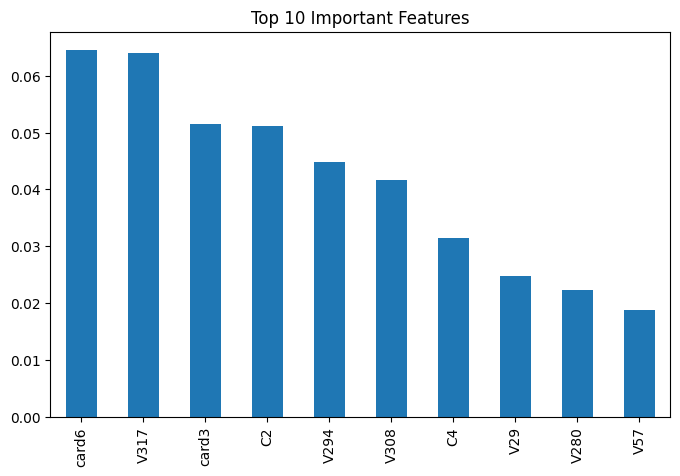

In [15]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)
top_features = feature_importance.sort_values(
    ascending=False
).head(10)
plt.figure(figsize=(8,5))
top_features.plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()